In [ ]:
from __future__ import annotations

from pathlib import Path
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import deque

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt


# Stability / performance settings
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
cv2.setNumThreads(1)

IO_WORKERS = 2

In [ ]:
# paths
PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "data" / "raw"
OUT_BASE = PROJECT_DIR / "data" / "vid_008_output_fin"

CORRECTED_DIR = OUT_BASE / "corrected_norm"
BINARY_DIR = OUT_BASE / "binary_black"
OVERLAY_DIR = OUT_BASE / "overlay_frames"
RESULTS_DIR = OUT_BASE / "results"

for p in [CORRECTED_DIR, BINARY_DIR, OVERLAY_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)


# vide_008
VIDEOS = sorted(RAW_DIR.glob("*.mp4"))
if not VIDEOS:
    raise FileNotFoundError(f"No .mp4 videos found in {RAW_DIR}")

matches = [p for p in VIDEOS if "vid_008" in p.stem]
if not matches:
    raise FileNotFoundError(f"vid_008 not found in {RAW_DIR}. Found examples: {[v.name for v in VIDEOS[:10]]}")

VIDEO_PATH = matches[0]
print("Using video:", VIDEO_PATH.name)


# Small display helpers

def show(img, title="", cmap="gray", figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_column(images, titles, figsize=(8, 18)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, (img, t) in enumerate(zip(images, titles), start=1):
        plt.subplot(n, 1, i)
        plt.imshow(img, cmap="gray")
        plt.title(t)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


# Read middle frame and choose ROI once

def get_middle_frame_bgr(video_path: Path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    mid = frame_count // 2
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid)

    ret, frame_bgr = cap.read()
    cap.release()

    if not ret:
        raise RuntimeError(f"Could not read middle frame {mid}")

    return frame_bgr, frame_count, mid


frame_bgr_mid, FRAME_COUNT, MID_ID = get_middle_frame_bgr(VIDEO_PATH)
print("frame_count:", FRAME_COUNT, "| mid frame:", MID_ID)

# ROI part
tmp = frame_bgr_mid.copy()
x, y, w, h = cv2.selectROI("Select ROI for vid_008 (press ENTER)", tmp, fromCenter=False, showCrosshair=True)
cv2.destroyAllWindows()

ROI = dict(x0=int(x), y0=int(y), w=int(w), h=int(h))
print("ROI =", ROI)


def crop_bgr(frame_bgr: np.ndarray, roi: dict) -> np.ndarray:
    x0, y0, w, h = roi["x0"], roi["y0"], roi["w"], roi["h"]
    return frame_bgr[y0:y0+h, x0:x0+w]


# Preprocessing: crop first, then two-stage Gaussian

def preprocess_corrected_norm(gray_roi: np.ndarray, k_small: int = 5, K_big: int = 101) -> np.ndarray:
    """
    Two-stage Gaussian logic:
      1) small blur removes local noise
      2) large blur estimates smooth background illumination
      3) background - smoothed image makes dark particles become bright
      4) normalize to 0..255 for easier thresholding
    """
    gray_smooth = cv2.GaussianBlur(gray_roi, (k_small, k_small), 0)
    background = cv2.GaussianBlur(gray_smooth, (K_big, K_big), 0)

    corrected = cv2.subtract(background, gray_smooth)
    corrected_norm = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX)

    return corrected_norm


# Thresholding to black particles on white background
def threshold_to_black_particles(
    corrected_norm: np.ndarray,
    method: str = "percentile",
    percentile_keep: float = 99.5
):
    """
    Output:
      - T_used
      - binary_black: particles = 0, background = 255
    """
    if method == "percentile":
        T_used = float(np.percentile(corrected_norm, percentile_keep))
    elif method == "otsu":
        T_used, _ = cv2.threshold(corrected_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        T_used = float(T_used)
    else:
        raise ValueError("method must be 'percentile' or 'otsu'")

    _, binary_black = cv2.threshold(corrected_norm, T_used, 255, cv2.THRESH_BINARY_INV)
    return T_used, binary_black


# Morphological cleanup

def clean_binary_black(binary_black: np.ndarray) -> np.ndarray:
    """
    Morphology is easier with white foreground.
    So:
      black particles -> invert -> clean -> invert back
    """
    binary_white = cv2.bitwise_not(binary_black)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    opened = cv2.morphologyEx(binary_white, cv2.MORPH_OPEN, kernel, iterations=1)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=1)

    binary_black_clean = cv2.bitwise_not(closed)
    return binary_black_clean


# Binary region labeling (connected components)
def extract_regions_by_labeling(binary_black_clean: np.ndarray, frame_idx: int, roi: dict) -> list[dict]:
    """
    Connected-component labeling on the cleaned binary image.

    Since particles are black in binary_black_clean, invert first so that
    particles become white connected foreground regions.
    """
    binary_white = cv2.bitwise_not(binary_black_clean)

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        binary_white, connectivity=8
    )

    rows = []
    for label_id in range(1, num_labels):  # skip label 0 = background
        x, y, w, h, area = stats[label_id]
        cx_roi, cy_roi = centroids[label_id]

        rows.append({
            "frame": int(frame_idx),
            "blob_id": int(label_id),
            "x_roi": float(cx_roi),
            "y_roi": float(cy_roi),
            "x": float(cx_roi + roi["x0"]),
            "y": float(cy_roi + roi["y0"]),
            "area": float(area),
            "bbox_x_roi": int(x),
            "bbox_y_roi": int(y),
            "bbox_w": int(w),
            "bbox_h": int(h),
            "bbox_x": int(x + roi["x0"]),
            "bbox_y": int(y + roi["y0"]),
        })

    return rows

# new add
def binary_black_outline(binary_black_clean: np.ndarray, thickness: int = 2) -> np.ndarray:
    """
    Input:
        binary_black_clean: white background, black filled particles
    Output:
        white background, black particle outlines only, white inside
    """
    binary_white = cv2.bitwise_not(binary_black_clean)  # particles -> white
    contours, _ = cv2.findContours(binary_white, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    outline = np.full_like(binary_black_clean, 255)  # white canvas
    cv2.drawContours(outline, contours, -1, 0, thickness=thickness)  # black outlines

    return outline


# Candidate filtering
def filter_regions(rows: list[dict], min_area: float = 10, max_area: float = 5000) -> list[dict]:
    """
    Remove obvious noise and obvious huge junk/artifacts.
    """
    return [r for r in rows if min_area <= r["area"] <= max_area]


# Candidate scoring for tracking the moving particle
def choose_best_region(
    rows: list[dict],
    last_xy: tuple[float, float] | None,
    area_history: deque,
    search_radius: float = 35.0,
    fallback_radius: float = 80.0,
):
    """
    Soft decision rule:
      - if no previous point: pick a reasonable seed (small/medium region)
      - otherwise prefer temporal continuity
      - also prefer area consistency with recent tracked particle area

    Returns:
      best_row or None
    """
    if not rows:
        return None

    if last_xy is None:
        # Initial seed: prefer median-like area rather than largest
        areas = np.array([r["area"] for r in rows], dtype=float)
        med_area = np.median(areas)

        def seed_score(r):
            return abs(r["area"] - med_area)

        return min(rows, key=seed_score)

    # Estimate expected area from recent tracked areas
    if len(area_history) > 0:
        expected_area = float(np.median(area_history))
    else:
        expected_area = float(np.median([r["area"] for r in rows]))

    candidates = []
    for r in rows:
        dx = r["x"] - last_xy[0]
        dy = r["y"] - last_xy[1]
        dist = float(np.sqrt(dx * dx + dy * dy))
        area_diff = abs(r["area"] - expected_area)

        # Main score: continuity first, area consistency second
        score = dist + 0.25 * area_diff

        candidates.append({
            "row": r,
            "dist": dist,
            "area_diff": area_diff,
            "score": score,
        })

    # First try tighter continuity
    near = [c for c in candidates if c["dist"] <= search_radius]
    if near:
        return min(near, key=lambda c: c["score"])["row"]

    # Then looser fallback
    wider = [c for c in candidates if c["dist"] <= fallback_radius]
    if wider:
        return min(wider, key=lambda c: c["score"])["row"]

    # Otherwise tracking likely failed this frame
    return None


# Draw labeled boxes/centroids on cropped frame for debugging

def draw_regions_on_crop(
    roi_bgr: np.ndarray,
    rows: list[dict],
    picked_row: dict | None = None
) -> np.ndarray:
    out = roi_bgr.copy()

    for r in rows:
        x = r["bbox_x_roi"]
        y = r["bbox_y_roi"]
        w = r["bbox_w"]
        h = r["bbox_h"]

        cv2.rectangle(out, (x, y), (x + w, y + h), (255, 255, 0), 1)
        cx = int(round(r["x_roi"]))
        cy = int(round(r["y_roi"]))
        cv2.circle(out, (cx, cy), 2, (0, 255, 255), -1)

    if picked_row is not None:
        cx = int(round(picked_row["x_roi"]))
        cy = int(round(picked_row["y_roi"]))
        cv2.circle(out, (cx, cy), 5, (0, 255, 0), -1)
        cv2.putText(out, "TRACKED", (cx + 8, cy - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 255, 0), 1, cv2.LINE_AA)

    return out


# Saving helper

def save_image(path: Path, img: np.ndarray):
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), img)

Using video: vid_008.mp4
frame_count: 2218 | mid frame: 1109
ROI = {'x0': 614, 'y0': 435, 'w': 256, 'h': 170}


In [ ]:
# Main processing pipeline

def process_vid_008_pipeline(
    video_path: Path,
    roi: dict,
    corrected_dir: Path,
    binary_dir: Path,
    overlay_dir: Path,
    results_dir: Path,
    k_small: int = 5,
    K_big: int = 101,
    threshold_method: str = "percentile",
    percentile_keep: float = 99.5,
    min_area: float = 10,
    max_area: float = 5000,
    search_radius: float = 35.0,
    fallback_radius: float = 80.0,
    save_every: int = 1,
):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print("Processing frames:", frame_count)

    all_rows = []
    last_xy = None
    area_history = deque(maxlen=10)

    io_pool = ThreadPoolExecutor(max_workers=IO_WORKERS)
    save_jobs = []

    for fid in range(frame_count):
        ret, frame_bgr = cap.read()
        if not ret:
            break

        # Step 1: crop first
        roi_bgr = crop_bgr(frame_bgr, roi)
        gray_roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)

        # Step 2: two-stage Gaussian correction
        corrected_norm = preprocess_corrected_norm(gray_roi, k_small=k_small, K_big=K_big)

        # Step 3: threshold
        T_used, binary_black = threshold_to_black_particles(
            corrected_norm,
            method=threshold_method,
            percentile_keep=percentile_keep
        )

        # Step 4: morphology cleanup
        binary_black_clean = clean_binary_black(binary_black)

        binary_black_outline_img = binary_black_outline(binary_black_clean, thickness=2)

        # Step 5: binary region labeling
        rows = extract_regions_by_labeling(binary_black_clean, fid, roi)

        # Step 6: remove obvious garbage
        rows = filter_regions(rows, min_area=min_area, max_area=max_area)

        # Step 7: choose moving particle candidate
        picked = choose_best_region(
            rows=rows,
            last_xy=last_xy,
            area_history=area_history,
            search_radius=search_radius,
            fallback_radius=fallback_radius,
        )

        if picked is not None:
            last_xy = (picked["x"], picked["y"])
            area_history.append(picked["area"])

            out_row = dict(picked)
            out_row["thr"] = float(T_used)
            out_row["picked"] = 1
            out_row["missing"] = 0
            all_rows.append(out_row)
        else:
            # Keep frame record, but tracking failed
            if last_xy is None:
                all_rows.append({
                    "frame": fid,
                    "blob_id": -1,
                    "x_roi": np.nan,
                    "y_roi": np.nan,
                    "x": np.nan,
                    "y": np.nan,
                    "area": np.nan,
                    "bbox_x_roi": np.nan,
                    "bbox_y_roi": np.nan,
                    "bbox_w": np.nan,
                    "bbox_h": np.nan,
                    "bbox_x": np.nan,
                    "bbox_y": np.nan,
                    "thr": float(T_used),
                    "picked": 0,
                    "missing": 1,
                })
            else:
                all_rows.append({
                    "frame": fid,
                    "blob_id": -1,
                    "x_roi": np.nan,
                    "y_roi": np.nan,
                    "x": last_xy[0],
                    "y": last_xy[1],
                    "area": np.nan,
                    "bbox_x_roi": np.nan,
                    "bbox_y_roi": np.nan,
                    "bbox_w": np.nan,
                    "bbox_h": np.nan,
                    "bbox_x": np.nan,
                    "bbox_y": np.nan,
                    "thr": float(T_used),
                    "picked": 0,
                    "missing": 1,
                })

        # Debug overlay on cropped frame
        overlay_crop = draw_regions_on_crop(roi_bgr, rows, picked_row=picked)

        # Save outputs
        if save_every and (fid % save_every == 0):
            p_corr = corrected_dir / f"{video_path.stem}_f{fid:05d}_corrected_norm.png"
            p_bin = binary_dir / f"{video_path.stem}_f{fid:05d}_binary_black.png"
            p_ovr = overlay_dir / f"{video_path.stem}_f{fid:05d}_overlay.png"

            save_jobs.append(io_pool.submit(save_image, p_corr, corrected_norm))
            save_jobs.append(io_pool.submit(save_image, p_bin, binary_black_outline_img))
            save_jobs.append(io_pool.submit(save_image, p_ovr, overlay_crop))

    cap.release()

    for job in as_completed(save_jobs):
        _ = job.result()

    io_pool.shutdown(wait=True)

    df = pd.DataFrame(all_rows)

    csv_path = results_dir / f"{video_path.stem}_tracking.csv"
    df.to_csv(csv_path, index=False)

    print("Saved tracking CSV:", csv_path)
    return df, csv_path

In [ ]:
# Trajectory plot
def save_trajectory_plot(df_track: pd.DataFrame, out_path: Path):
    df_plot = df_track.copy()

    plt.figure(figsize=(6, 6))
    plt.plot(df_plot["x"], df_plot["y"], marker="o", markersize=2, linewidth=1)
    plt.title("Trajectory: tracked particle over frames")
    plt.xlabel("x (pixels)")
    plt.ylabel("y (pixels)")
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()

    print("Saved trajectory plot:", out_path)

In [ ]:
# Cropped overlay video with trajectory drawn progressively
def make_cropped_trajectory_video(
    video_path: Path,
    df_track: pd.DataFrame,
    roi: dict,
    out_path: Path,
    draw_path: bool = True,
    point_radius: int = 4,
    line_thickness: int = 2,
):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    roi_w = roi["w"]
    roi_h = roi["h"]

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, fps, (roi_w, roi_h))

    df_use = df_track.sort_values("frame").reset_index(drop=True)
    history_roi = []

    for fid in range(frame_count):
        ret, frame_bgr = cap.read()
        if not ret:
            break

        roi_bgr = crop_bgr(frame_bgr, roi).copy()

        row_now = df_use[df_use["frame"] == fid]
        if len(row_now) > 0:
            x_full = row_now.iloc[0]["x"]
            y_full = row_now.iloc[0]["y"]

            if pd.notna(x_full) and pd.notna(y_full):
                x_roi = int(round(x_full - roi["x0"]))
                y_roi = int(round(y_full - roi["y0"]))
                history_roi.append((x_roi, y_roi))

        if draw_path:
            for i in range(1, len(history_roi)):
                cv2.line(roi_bgr, history_roi[i-1], history_roi[i], (0, 0, 255), line_thickness)

        if len(history_roi) > 0:
            cv2.circle(roi_bgr, history_roi[-1], point_radius, (0, 255, 0), -1)

        cv2.putText(
            roi_bgr,
            f"frame={fid}",
            (10, 25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

        writer.write(roi_bgr)

    cap.release()
    writer.release()

    print("Saved cropped trajectory video:", out_path)

Processing frames: 2218
Saved tracking CSV: C:\Users\milli\Desktop\capstone_project\data\vid_008_output_fin\results\vid_008_tracking.csv


,frame,blob_id,x_roi,y_roi,x,y,area,bbox_x_roi,bbox_y_roi,bbox_w,bbox_h,bbox_x,bbox_y,thr,picked,missing
0,0,1,105.433333,75.266667,719.433333,510.266667,30.0,102,73,8,5,716,508,104.0,1,0
1,1,1,105.433333,75.266667,719.433333,510.266667,30.0,102,73,8,5,716,508,105.0,1,0
2,2,1,105.083333,74.708333,719.083333,509.708333,24.0,102,72,7,6,716,507,105.0,1,0
3,3,1,105.043478,74.826087,719.043478,509.826087,23.0,102,73,7,5,716,508,105.0,1,0
4,4,1,106.230769,74.769231,720.230769,509.769231,13.0,104,73,5,4,718,508,109.0,1,0


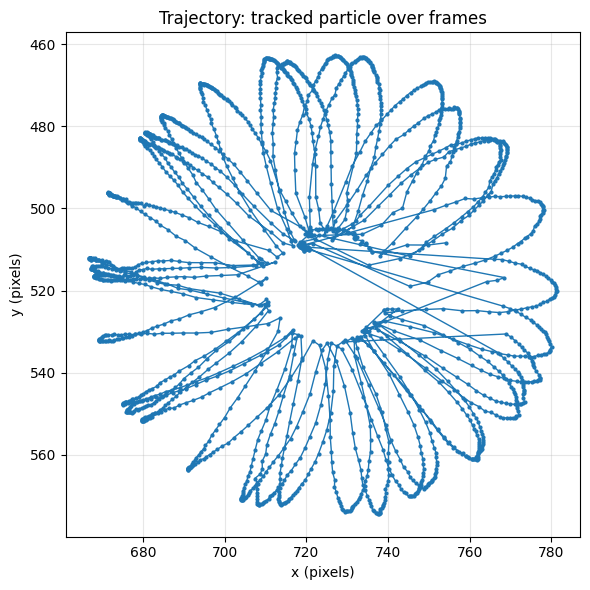

Saved trajectory plot: C:\Users\milli\Desktop\capstone_project\data\vid_008_output_fin\results\vid_008_trajectory.png
Saved cropped trajectory video: C:\Users\milli\Desktop\capstone_project\data\vid_008_output_fin\results\vid_008_cropped_trajectory_overlay.mp4
Done.


In [ ]:
# Run everything
df_track, csv_path = process_vid_008_pipeline(
    video_path=VIDEO_PATH,
    roi=ROI,
    corrected_dir=CORRECTED_DIR,
    binary_dir=BINARY_DIR,
    overlay_dir=OVERLAY_DIR,
    results_dir=RESULTS_DIR,
    k_small=5,
    K_big=101,
    threshold_method="percentile",   # try "otsu" too if needed
    percentile_keep=99.5,
    min_area=10,
    max_area=5000,
    search_radius=35.0,
    fallback_radius=80.0,
    save_every=1,
)

display(df_track.head())

trajectory_plot_path = RESULTS_DIR / f"{VIDEO_PATH.stem}_trajectory.png"
save_trajectory_plot(df_track, trajectory_plot_path)

cropped_video_path = RESULTS_DIR / f"{VIDEO_PATH.stem}_cropped_trajectory_overlay.mp4"
make_cropped_trajectory_video(
    video_path=VIDEO_PATH,
    df_track=df_track,
    roi=ROI,
    out_path=cropped_video_path,
    draw_path=True,
    point_radius=4,
    line_thickness=2,
)

print("Done.")